# News Image Probing Analysis
Load saved probing outputs, visualize image-level heatmaps, and inspect aggregate statistics.

In [12]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
sns.set_style("whitegrid")

In [13]:
# Locate and load the latest news-image probing outputs.
RESULTS_ROOT = Path("./results")
MODEL_SUBDIR = None  # set explicitly (e.g., "Qwen3-VL-8B-Instruct") to pin a run

if MODEL_SUBDIR is not None:
    search_root = RESULTS_ROOT / MODEL_SUBDIR
else:
    search_root = RESULTS_ROOT

score_candidates = sorted(
    glob.glob(str(search_root / "**" / "news_images_patch_scores.pt"), recursive=True),
    key=os.path.getmtime,
    reverse=True,
    )
stats_candidates = sorted(
    glob.glob(str(search_root / "**" / "news_images_patch_stats.csv"), recursive=True),
    key=os.path.getmtime,
    reverse=True,
    )

if not score_candidates:
    raise FileNotFoundError("Could not find news_images_patch_scores.pt under ./results")
if not stats_candidates:
    raise FileNotFoundError("Could not find news_images_patch_stats.csv under ./results")

SCORES_PATH = score_candidates[0]
STATS_PATH = stats_candidates[0]

payload = torch.load(SCORES_PATH, map_location="cpu")
df_stats = pd.read_csv(STATS_PATH)

offsets = payload["offsets"].cpu().numpy()
scores = payload["scores"].cpu().numpy()
image_max_abs_scores = np.array(
    [
        float(scores[int(start):int(end)][np.argmax(np.abs(scores[int(start):int(end)]))]) if int(end) > int(start) else np.nan
        for start, end in zip(offsets[:-1], offsets[1:])
    ]
)

if len(image_max_abs_scores) == len(df_stats):
    df_stats["max_abs_score"] = image_max_abs_scores
else:
    print(
        "Warning: could not align computed max-absolute scores with stats rows "
        f"({len(image_max_abs_scores)} vs {len(df_stats)})."
    )

print(f"Loaded scores: {SCORES_PATH}")
print(f"Loaded stats : {STATS_PATH}")
print(f"Num images   : {len(payload['image_paths'])}")
print("Metadata:")
display(pd.Series(payload.get("metadata", {}), name="value"))

df_stats.head()

Loaded scores: results/qwen3-vl-8b-instruct/news_images_patch_scores.pt
Loaded stats : results/qwen3-vl-8b-instruct/news_images_patch_stats.csv
Num images   : 8992
Metadata:


model_path         /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
image_dir                                          data/news_images
ridge_prefix                                             politician
top_k                                                            16
prompt            write a possible news article that would best ...
max_width                                                       800
image_pad_id                                                 151655
skipped_images                                                   14
Name: value, dtype: object

,image_name,image_path,grid_h,grid_w,num_patches,mean,median,min,max,std,max_abs_score
0,82.jpg,data/news_images/data/data_2016/bing/cameron/b...,17,25,425,-0.011856,-0.018127,-0.432129,0.547607,0.144939,0.547607
1,96.jpg,data/news_images/data/data_2016/bing/cameron/b...,16,25,400,-0.115316,-0.090118,-0.887085,0.338654,0.182173,-0.887085
2,48.jpg,data/news_images/data/data_2016/bing/cameron/h...,21,25,525,-0.203239,-0.127808,-1.557617,0.512817,0.297397,-1.557617
3,62.jpg,data/news_images/data/data_2016/bing/cameron/h...,17,25,425,-0.352183,-0.285522,-1.870850,0.400696,0.294880,-1.870850
4,82.jpg,data/news_images/data/data_2016/bing/cameron/h...,14,25,350,0.042356,0.019814,-0.496918,1.605713,0.236949,1.605713


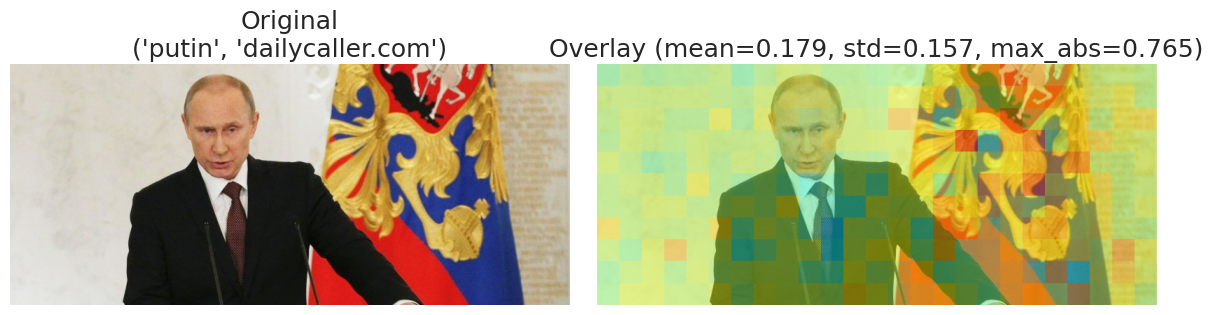

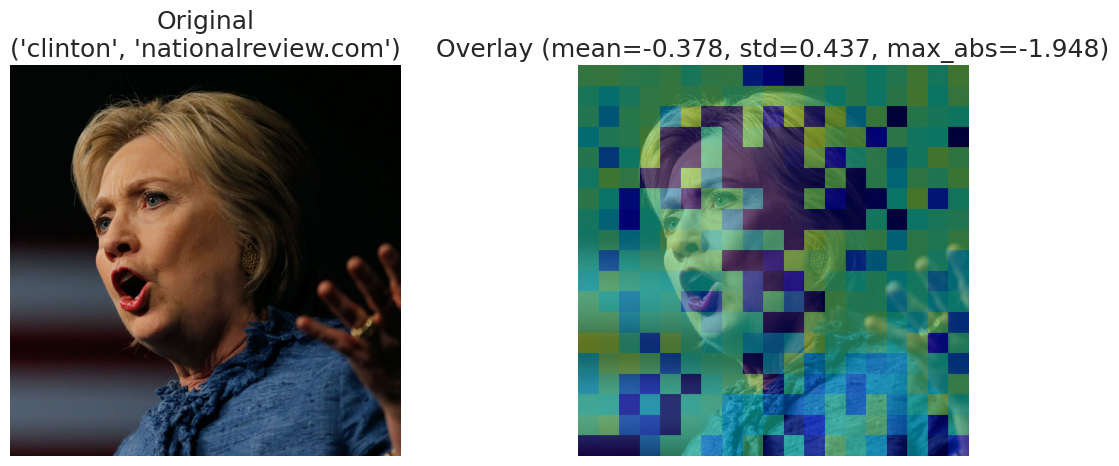

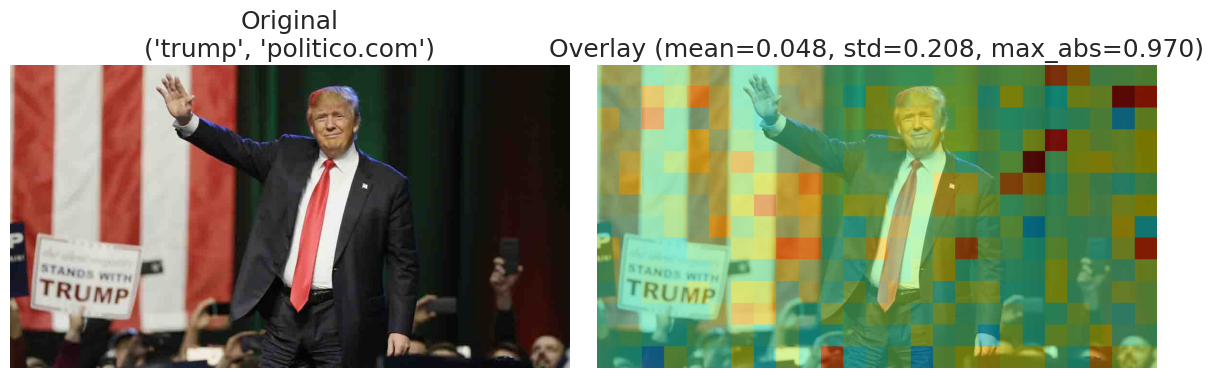

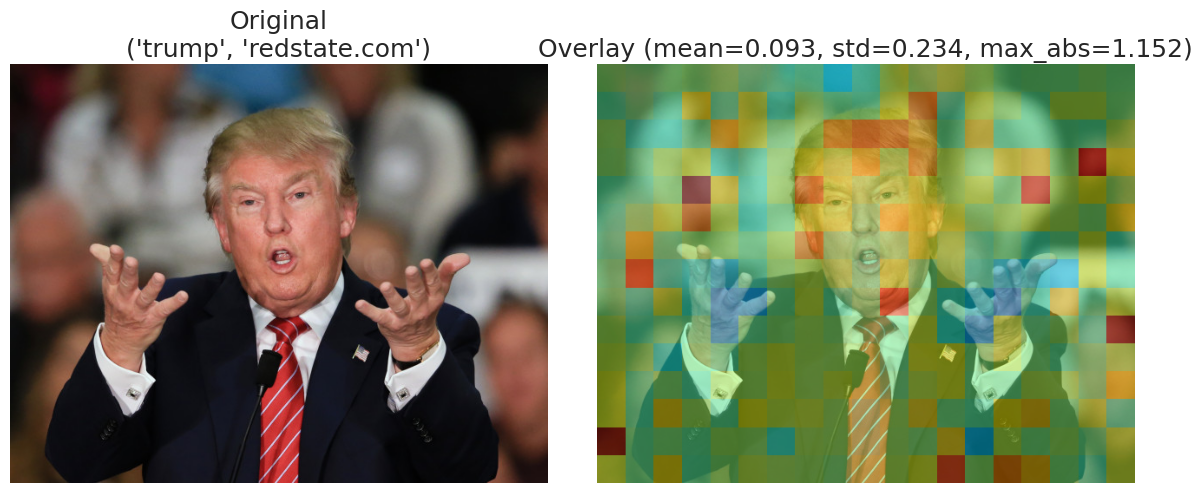

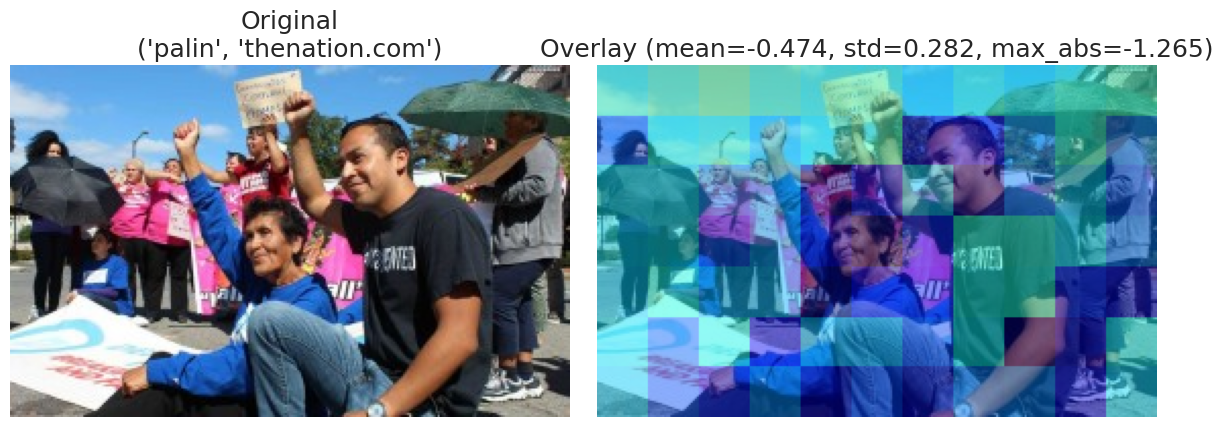

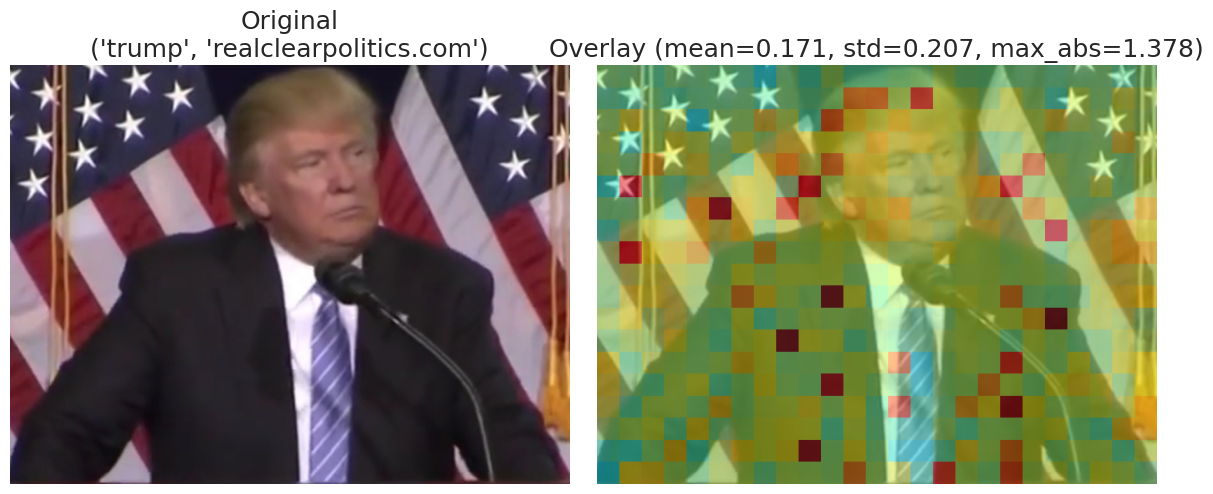

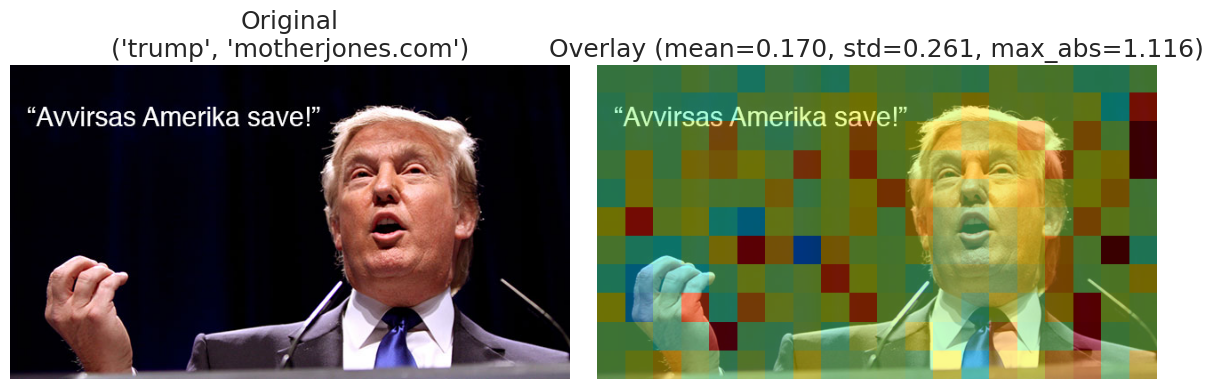

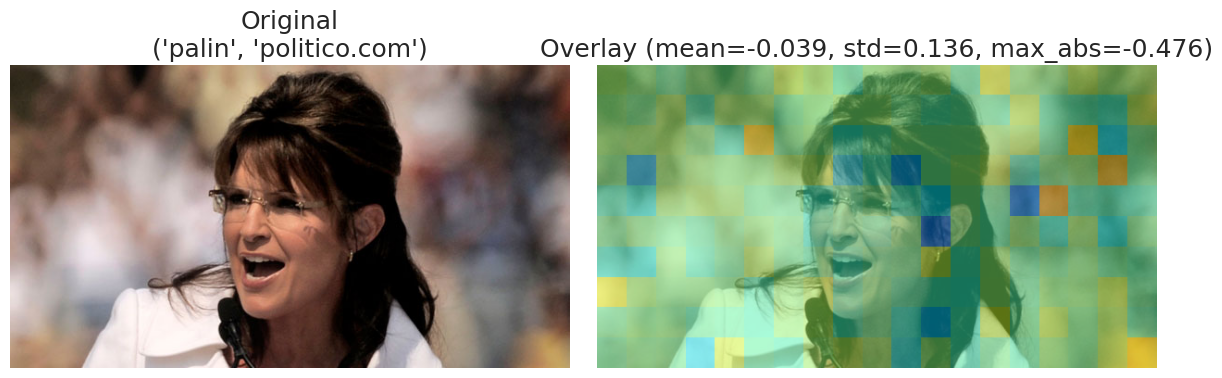

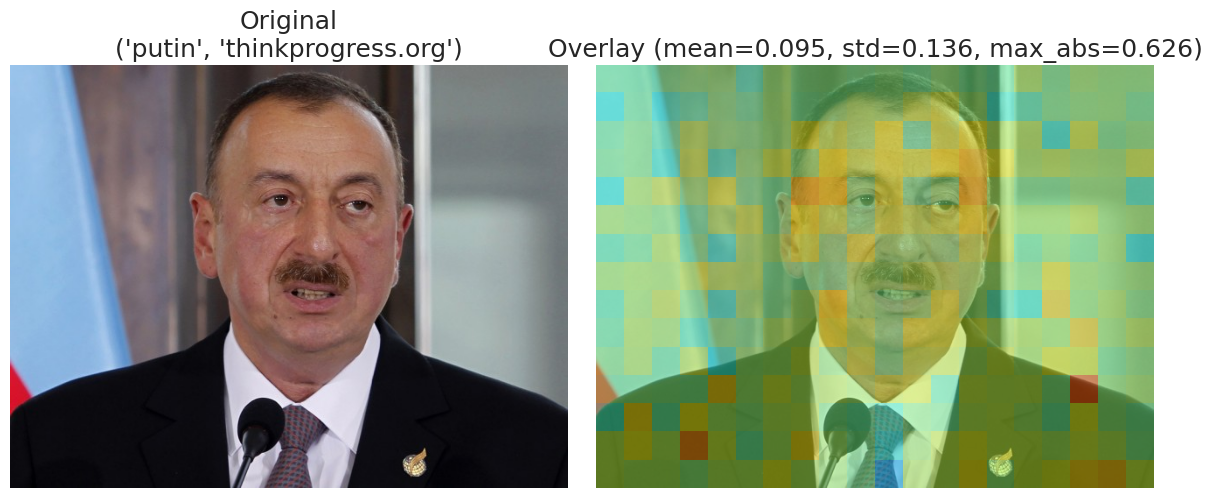

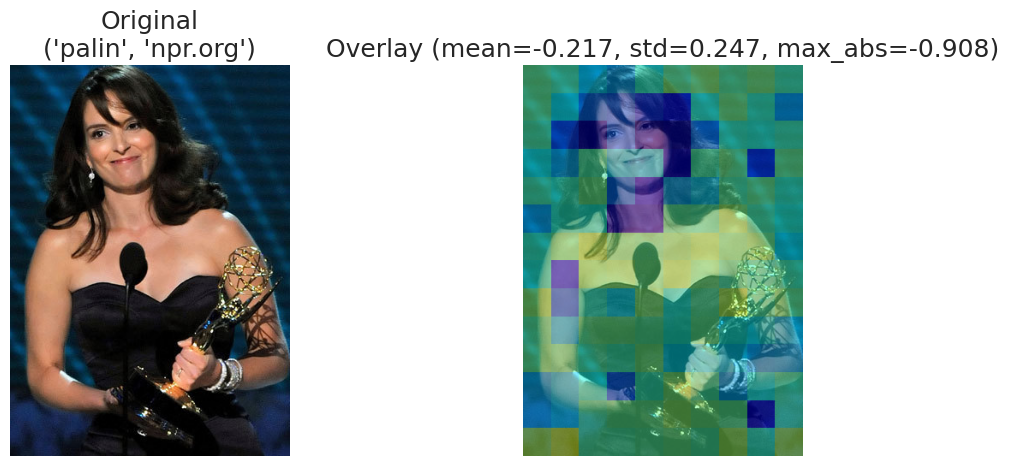

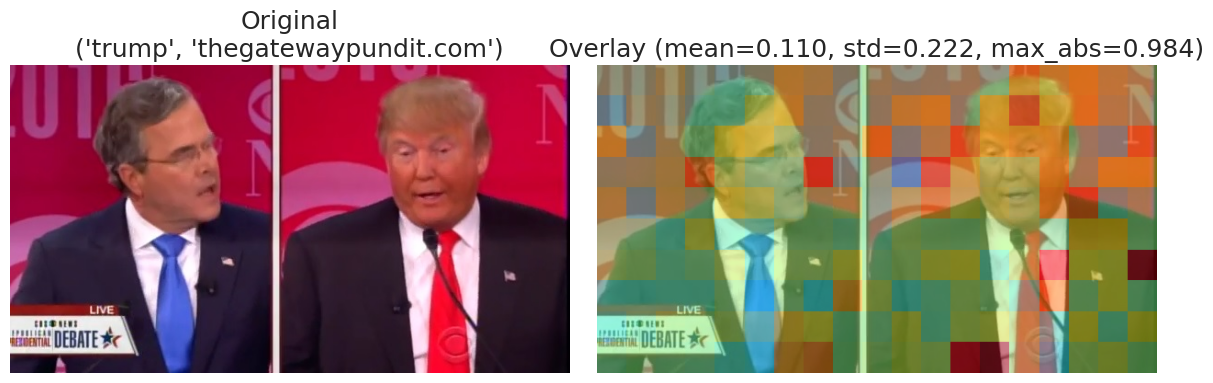

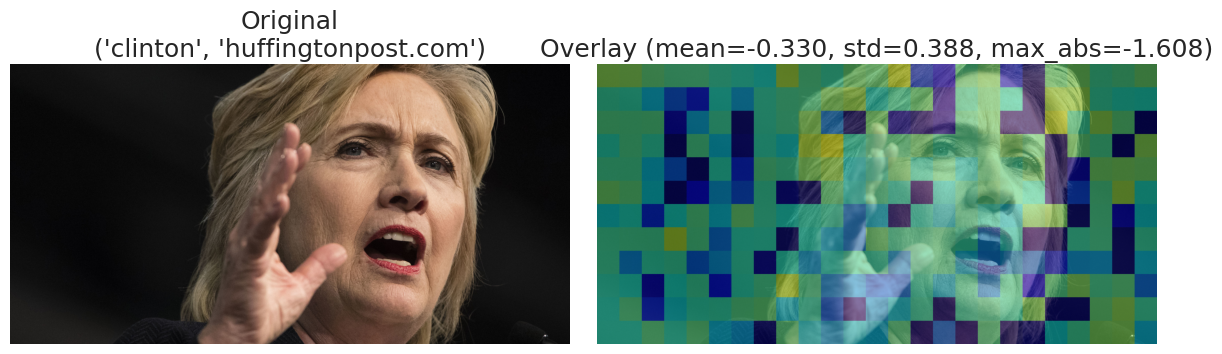

In [18]:
# Helpers to reconstruct per-image score maps and overlay heatmaps.
def get_image_scores_for_index(idx: int):
    offsets = payload["offsets"].numpy()
    scores = payload["scores"].numpy()
    start, end = int(offsets[idx]), int(offsets[idx + 1])
    return scores[start:end]

def overlay_heatmap_on_image(img_pil, heatmap_hw, alpha=0.45, cmap="jet", vmin=None, vmax=None):
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    H, W = img.shape[:2]

    hm = heatmap_hw.astype(np.float32)
    if vmin is None:
        vmin = float(np.nanmin(hm))
    if vmax is None:
        vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)

    hm_up = np.array(
        Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.Resampling.NEAREST)
    ) / 255.0

    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]
    out = (1 - alpha) * img + alpha * hm_rgb
    return np.clip(out, 0.0, 1.0)

def show_heatmap_examples(n=6, seed=42):
    n_total = len(payload["image_paths"])
    if n_total == 0:
        print("No images in payload.")
        return

    rng = np.random.default_rng(seed)
    choices = rng.choice(n_total, size=min(n, n_total), replace=False)

    for idx in choices:
        image_path = payload["image_paths"][idx]
        grid_h, grid_w = payload["grid_hw"][idx].tolist()
        flat_scores = get_image_scores_for_index(idx)

        if len(flat_scores) != grid_h * grid_w:
            print(f"Skipping {image_path}: score length mismatch")
            continue

        max_abs_score = float(flat_scores[np.argmax(np.abs(flat_scores))])
        heat = flat_scores.reshape(grid_h, grid_w)
        img = Image.open(image_path).convert("RGB")
        over = overlay_heatmap_on_image(img, heat, alpha=0.45, cmap="jet", vmin=-1, vmax=1)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img)
        axes[0].set_title(f"Original\n{Path(image_path).parts[-3:-1]}")
        axes[0].axis("off")

        axes[1].imshow(over)
        axes[1].set_title(
            "Overlay "
            f"(mean={float(np.mean(flat_scores)):.3f}, std={float(np.std(flat_scores)):.3f}, "
            f"max_abs={max_abs_score:.3f})"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

show_heatmap_examples(n=12, seed=7)

,count,mean,std,min,25%,50%,75%,max
mean,8992.0,-0.056539,0.184909,-0.698225,-0.218566,-0.025285,0.099462,1.374051
median,8992.0,-0.034259,0.132622,-0.476929,-0.142738,-0.024546,0.078751,1.350861
min,8992.0,-0.849145,0.594056,-2.700867,-1.338913,-0.561188,-0.392212,-0.006714
max,8992.0,0.686416,0.445506,-0.084595,0.329834,0.538483,1.028053,3.479004
std,8992.0,0.252654,0.097815,0.073692,0.179207,0.225609,0.320010,0.811388
num_patches,8992.0,296.993439,125.416609,64.000000,209.000000,300.000000,361.000000,975.000000
max_abs_score,8992.0,-0.133528,1.243075,-2.700867,-1.337860,0.343887,1.020302,3.479004


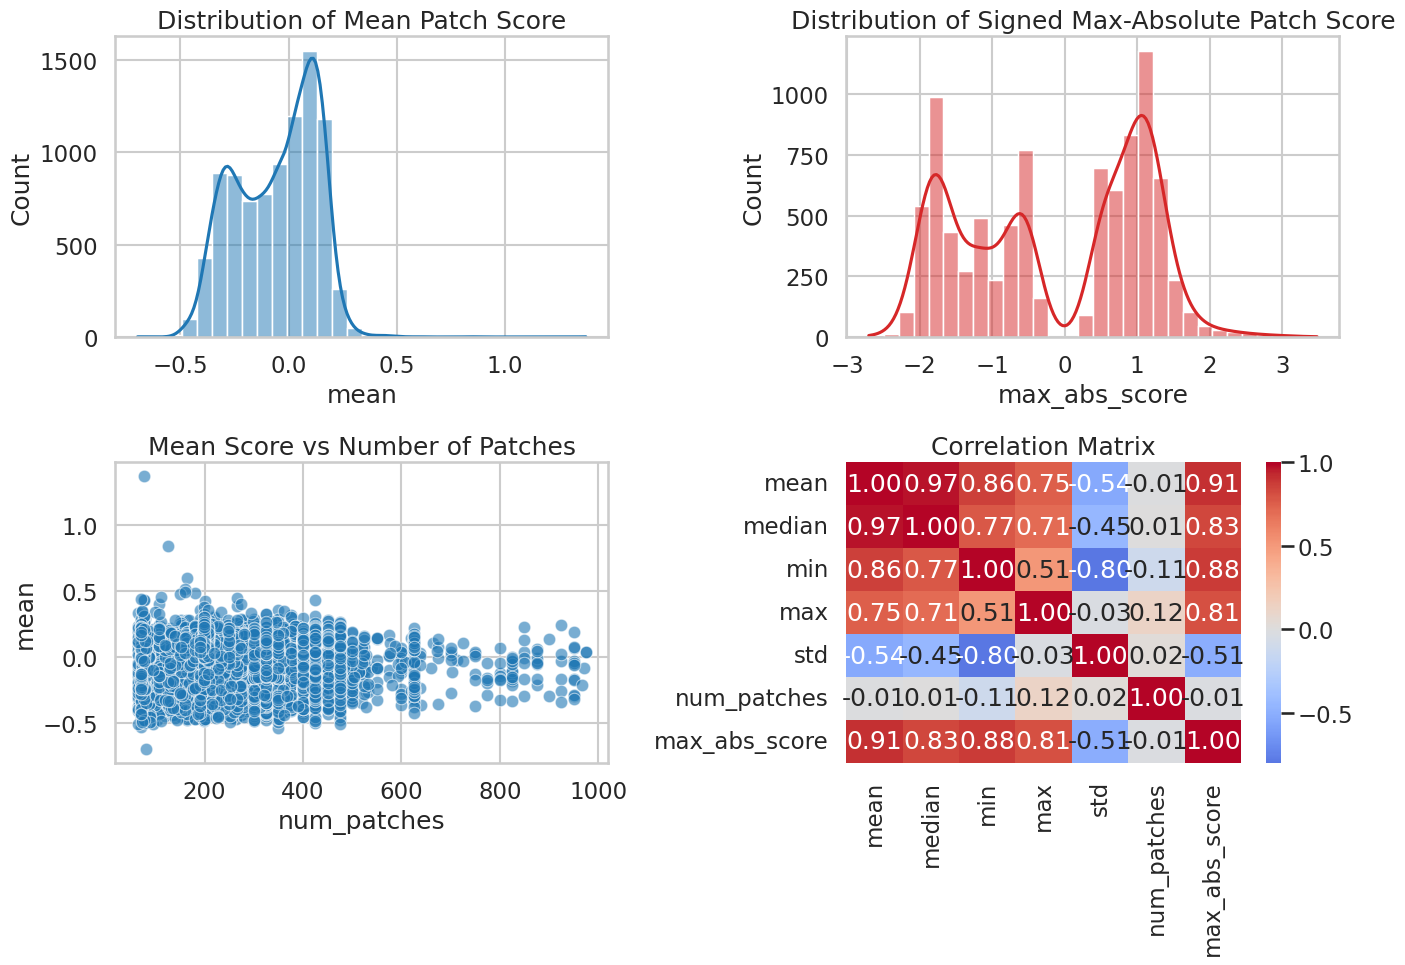

Top 10 by mean score


,image_name,image_path,num_patches,mean,std,min,max,max_abs_score
6322,84.jpg,data/news_images/data/data_2017/bing/palin/the...,78,1.374051,0.811388,-0.006714,2.833252,2.833252
1537,87.jpg,data/news_images/data/data_2016/bing/putin/red...,126,0.843674,0.580018,-0.373779,2.247040,2.247040
4807,43.jpg,data/news_images/data/data_2017/bing/palin/dai...,165,0.600602,0.432869,-0.201599,1.943817,1.943817
6407,42.jpg,data/news_images/data/data_2017/bing/palin/thi...,160,0.514530,0.667303,-0.742188,3.479004,3.479004
6454,90.jpg,data/news_images/data/data_2017/bing/palin/thi...,160,0.494607,0.609769,-0.740723,2.837982,2.837982
6060,56.jpg,data/news_images/data/data_2017/bing/palin/the...,180,0.486565,0.452555,-0.070312,1.867493,1.867493
6416,52.jpg,data/news_images/data/data_2017/bing/palin/thi...,150,0.480509,0.635231,-0.505127,3.003418,3.003418
2055,75.jpg,data/news_images/data/data_2016/bing/putin/thi...,112,0.456281,0.432157,-0.194214,1.666199,1.666199
6092,86.jpg,data/news_images/data/data_2017/bing/palin/the...,266,0.445938,0.567649,-0.509399,2.940735,2.940735
7872,134.jpg,data/news_images/data/data_2017/bing/trump/rea...,70,0.439349,0.462923,-0.088013,1.791504,1.791504


Bottom 10 by mean score


,image_name,image_path,num_patches,mean,std,min,max,max_abs_score
6014,145.jpg,data/news_images/data/data_2017/bing/palin/the...,81,-0.698225,0.605904,-2.003296,0.114258,-2.003296
89,130.jpg,data/news_images/data/data_2016/bing/clinton/n...,350,-0.533726,0.356780,-2.238770,0.210815,-2.238770
934,136.jpg,data/news_images/data/data_2016/bing/putin/npr...,70,-0.528632,0.287121,-1.100098,0.054718,-1.100098
4207,138.jpg,data/news_images/data/data_2017/bing/clinton/t...,475,-0.510337,0.350062,-2.029053,0.073792,-2.029053
3707,64.jpg,data/news_images/data/data_2017/bing/clinton/r...,64,-0.510020,0.513817,-1.736816,0.083252,-1.736816
3015,129.jpg,data/news_images/data/data_2017/bing/clinton/n...,96,-0.504278,0.466148,-1.839355,0.065277,-1.839355
2080,118.jpg,data/news_images/data/data_2016/bing/sanders/r...,425,-0.499162,0.388409,-2.211670,0.083221,-2.211670
3494,130.jpg,data/news_images/data/data_2017/bing/clinton/r...,80,-0.498684,0.435363,-1.614868,0.086182,-1.614868
2850,111.jpg,data/news_images/data/data_2017/bing/clinton/n...,350,-0.491897,0.326725,-2.028320,0.087463,-2.028320
6394,28.jpg,data/news_images/data/data_2017/bing/palin/thi...,72,-0.491624,0.321740,-1.310303,0.067688,-1.310303


Top 10 by signed max-absolute patch score


,image_name,image_path,num_patches,mean,std,min,max,max_abs_score
6407,42.jpg,data/news_images/data/data_2017/bing/palin/thi...,160,0.514530,0.667303,-0.742188,3.479004,3.479004
8414,107.jpg,data/news_images/data/data_2017/bing/trump/the...,198,0.259374,0.504797,-0.525269,3.267334,3.267334
154,72.jpg,data/news_images/data/data_2016/bing/cruz/thin...,425,0.124267,0.429123,-0.522095,3.159603,3.159603
6039,37.jpg,data/news_images/data/data_2017/bing/palin/the...,150,0.255126,0.427696,-0.112122,3.149780,3.149780
8477,30.jpg,data/news_images/data/data_2017/bing/trump/the...,345,0.268439,0.441818,-0.597412,3.066650,3.066650
6297,60.jpg,data/news_images/data/data_2017/bing/palin/the...,380,0.247725,0.447943,-0.370117,3.055695,3.055695
4970,66.jpg,data/news_images/data/data_2017/bing/palin/huf...,425,0.186952,0.497873,-0.459167,3.016235,3.016235
6416,52.jpg,data/news_images/data/data_2017/bing/palin/thi...,150,0.480509,0.635231,-0.505127,3.003418,3.003418
6092,86.jpg,data/news_images/data/data_2017/bing/palin/the...,266,0.445938,0.567649,-0.509399,2.940735,2.940735
5084,82.jpg,data/news_images/data/data_2017/bing/palin/mot...,425,0.433966,0.482173,-0.390869,2.926331,2.926331


In [15]:
# Statistical views of per-image probing scores.
df_plot = df_stats.copy()

required_cols = ["mean", "median", "min", "max", "std", "num_patches"]
missing = [c for c in required_cols if c not in df_plot.columns]
if missing:
    raise ValueError(f"Missing expected columns in stats CSV: {missing}")

summary_cols = required_cols + [c for c in ["max_abs_score"] if c in df_plot.columns]
summary = df_plot[summary_cols].describe().T
display(summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_plot["mean"], bins=30, kde=True, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Distribution of Mean Patch Score")

if "max_abs_score" in df_plot.columns:
    sns.histplot(df_plot["max_abs_score"], bins=30, kde=True, ax=axes[0, 1], color="tab:red")
    axes[0, 1].set_title("Distribution of Signed Max-Absolute Patch Score")
else:
    sns.histplot(df_plot["std"], bins=30, kde=True, ax=axes[0, 1], color="tab:orange")
    axes[0, 1].set_title("Distribution of Patch Score Std")

sns.scatterplot(data=df_plot, x="num_patches", y="mean", alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Mean Score vs Number of Patches")

corr_cols = summary_cols
corr = df_plot[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0.0, annot=True, fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

# Show top/bottom examples by mean score.
cols_to_show = [
    c for c in ["image_name", "image_path", "num_patches", "mean", "std", "min", "max", "max_abs_score"]
    if c in df_plot.columns
]
print("Top 10 by mean score")
display(df_plot.sort_values("mean", ascending=False)[cols_to_show].head(10))

print("Bottom 10 by mean score")
display(df_plot.sort_values("mean", ascending=True)[cols_to_show].head(10))

if "max_abs_score" in df_plot.columns:
    print("Top 10 by signed max-absolute patch score")
    display(df_plot.reindex(df_plot["max_abs_score"].abs().sort_values(ascending=False).index)[cols_to_show].head(10))

In [21]:
website_to_moniker_name = {
    "breitbart.com": "Breitbart",
    "huffingtonpost.com": "HuffPost",
    "motherjones.com": "Mother Jones",
    "npr.org": "NPR (website)",
    "realclearpolitics.com": "RealClearPolitics",
    "thenation.com": "The Nation",
    "therightscoop.com": None,
    "thinkprogress.org": None,
    "dailycaller.com": "Daily Caller",
    "foxnews.com": "Fox News (website)",
    "news.yahoo.com": "Yahoo.com",
    "politico.com": "Politico",
    "redstate.com": "RedState",
    "theatlantic.com": "The Atlantic",
    "washingtonpost.com": "Washington Post",
    "cnn.com": "CNN (website)",
    "rawstory.com": "Raw Story",
    "thegatewaypundit.com": "The Gateway Pundit",
    "nytimes.com": "The New York Times",
    "politicususa.com": "PoliticusUSA",
    "reuters.com": "Reuters",
    "nationalreview.com": "National Review",
    "americanthinker.com": "American Thinker",
}

Top persons by image count


,person,n_images,mean_score,median_score
0,Trump,2558,0.100762,0.119791
1,Clinton,2214,-0.272948,-0.294632
2,Palin,1827,-0.029240,-0.031969
3,Putin,1817,-0.008325,0.011817
4,Obama,398,-0.198313,-0.204265
5,Cameron,71,-0.047744,-0.057284
6,Sanders,39,-0.207503,-0.204871
7,Merkel,24,-0.072722,-0.100765
8,Cruz,22,0.076450,0.113223
9,Xi,21,-0.132429,-0.138987


Top outlets by image count


,outlet,n_images,mean_score,median_score
0,huffingtonpost.com,725,-0.079612,-0.072220
1,breitbart.com,695,-0.094000,-0.103963
2,npr.org,600,-0.068131,-0.042747
3,politico.com,592,-0.061504,-0.043435
4,nytimes.com,580,-0.068107,-0.038200
5,dailycaller.com,566,-0.059941,-0.041144
6,realclearpolitics.com,548,-0.056559,-0.035503
7,nationalreview.com,512,-0.043151,0.032087
8,thegatewaypundit.com,503,-0.055000,-0.024300
9,thinkprogress.org,501,-0.035297,0.009568


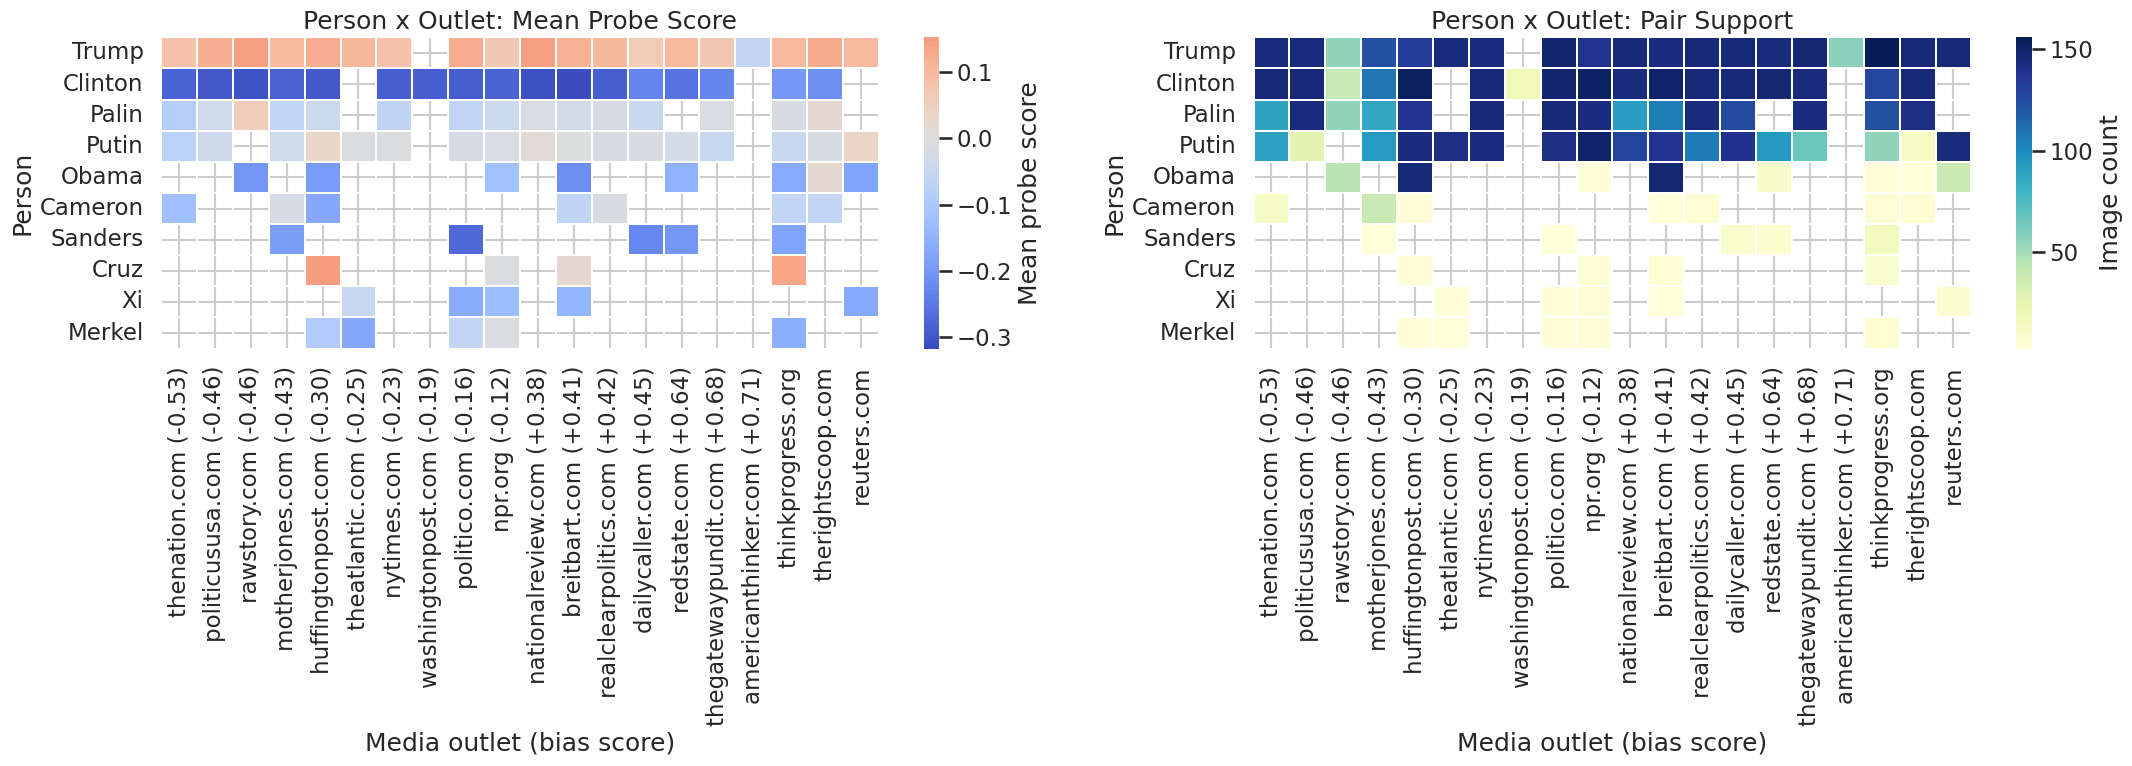

,person,outlet,pair_count,pair_mean_score,pair_median_score
113,Trump,thinkprogress.org,156,0.099574,0.117909
10,Clinton,huffingtonpost.com,153,-0.294158,-0.293365
13,Clinton,npr.org,152,-0.283240,-0.288475
74,Putin,npr.org,150,-0.008259,-0.003180
8,Clinton,breitbart.com,150,-0.317374,-0.323095
103,Trump,politico.com,149,0.127813,0.131772
15,Clinton,politico.com,148,-0.292583,-0.295959
110,Trump,thegatewaypundit.com,147,0.071553,0.102049
42,Obama,breitbart.com,147,-0.214958,-0.221524
19,Clinton,redstate.com,147,-0.258082,-0.284378


In [23]:

# Visualize probing scores by person x media outlet.
import re

if "df_stats" not in globals():
    raise RuntimeError("Run the data-loading cell first so df_stats is available.")

df_group = df_stats.copy()

if "image_path" not in df_group.columns or "mean" not in df_group.columns:
    raise ValueError("Expected columns ['image_path', 'mean'] in df_stats.")

def parse_person_outlet(path_str: str):
    p = str(path_str).replace("\\", "/")
    parts = [x for x in p.split("/") if x]
    if len(parts) >= 3:
        person = parts[-3]
        outlet = parts[-2]
    else:
        person = "unknown_person"
        outlet = "unknown_outlet"

    # Light cleanup for readability.
    person = re.sub(r"[_-]+", " ", person).strip().title()
    outlet = outlet.strip().lower()
    return person, outlet

parsed = df_group["image_path"].apply(parse_person_outlet)
df_group[["person", "outlet"]] = pd.DataFrame(parsed.tolist(), index=df_group.index)

person_stats = (
    df_group.groupby("person", as_index=False)
    .agg(n_images=("mean", "size"), mean_score=("mean", "mean"), median_score=("mean", "median"))
    .sort_values("n_images", ascending=False)
    .reset_index(drop=True)
)

outlet_stats = (
    df_group.groupby("outlet", as_index=False)
    .agg(n_images=("mean", "size"), mean_score=("mean", "mean"), median_score=("mean", "median"))
    .sort_values("n_images", ascending=False)
    .reset_index(drop=True)
)

# Load Ad Fontes Media bias scores and build outlet-domain -> bias mapping.
df_bias = pd.read_csv("data/adfontesmedia.csv")
moniker_to_bias = dict(zip(df_bias["moniker_name"], df_bias["bias_mean"]))
outlet_to_bias = {
    domain: moniker_to_bias[moniker]
    for domain, moniker in website_to_moniker_name.items()
    if moniker is not None and moniker in moniker_to_bias
}

print("Top persons by image count")
display(person_stats.head(15))

print("Top outlets by image count")
display(outlet_stats.head(15))

# Restrict to sufficiently represented person/outlet pairs for a readable heatmap.
TOP_PERSONS = 20
TOP_OUTLETS = 20
MIN_PAIR_COUNT = 2

top_persons = person_stats.head(TOP_PERSONS)["person"].tolist()
top_outlets = outlet_stats.head(TOP_OUTLETS)["outlet"].tolist()

pair_stats = (
    df_group[df_group["person"].isin(top_persons) & df_group["outlet"].isin(top_outlets)]
    .groupby(["person", "outlet"], as_index=False)
    .agg(pair_count=("mean", "size"), pair_mean_score=("mean", "mean"), pair_median_score=("mean", "median"))
)

pair_stats = pair_stats[pair_stats["pair_count"] >= MIN_PAIR_COUNT].copy()

if pair_stats.empty:
    print("No person x outlet pairs passed MIN_PAIR_COUNT. Lower MIN_PAIR_COUNT to visualize more pairs.")
else:
    pivot_mean = pair_stats.pivot(index="person", columns="outlet", values="pair_mean_score")
    pivot_count = pair_stats.pivot(index="person", columns="outlet", values="pair_count")

    # Sort columns by Ad Fontes bias score (liberal left, conservative right);
    # fall back to support-based order for outlets without a bias score.
    outlets_in_pivot = list(pivot_mean.columns)
    outlets_with_bias = [o for o in outlets_in_pivot if o in outlet_to_bias]
    outlets_without_bias = [o for o in outlets_in_pivot if o not in outlet_to_bias]

    col_order_biased = sorted(outlets_with_bias, key=lambda o: outlet_to_bias[o])
    col_order_fallback = (
        pivot_count[outlets_without_bias].sum(axis=0)
        .sort_values(ascending=False)
        .index.tolist()
    ) if outlets_without_bias else []
    col_order = col_order_biased + col_order_fallback

    # Sort rows by support.
    row_order = pivot_count.sum(axis=1).sort_values(ascending=False).index

    pivot_mean = pivot_mean.loc[row_order, col_order]
    pivot_count = pivot_count.loc[row_order, col_order]

    # Build x-axis labels that include bias score where available.
    col_labels = [
        f"{o} ({outlet_to_bias[o]:+.2f})" if o in outlet_to_bias else o
        for o in pivot_mean.columns
    ]

    fig, axes = plt.subplots(1, 2, figsize=(22, max(8, 0.45 * len(row_order))))

    sns.heatmap(
        pivot_mean,
        ax=axes[0],
        cmap="coolwarm",
        center=0.0,
        cbar_kws={"label": "Mean probe score"},
        linewidths=0.2,
        linecolor="white",
        xticklabels=col_labels,
    )
    axes[0].set_title("Person x Outlet: Mean Probe Score")
    axes[0].set_xlabel("Media outlet (bias score)")
    axes[0].set_ylabel("Person")

    sns.heatmap(
        pivot_count,
        ax=axes[1],
        cmap="YlGnBu",
        cbar_kws={"label": "Image count"},
        linewidths=0.2,
        linecolor="white",
        xticklabels=col_labels,
    )
    axes[1].set_title("Person x Outlet: Pair Support")
    axes[1].set_xlabel("Media outlet (bias score)")
    axes[1].set_ylabel("Person")

    plt.tight_layout()
    plt.show()

# Detailed table for downstream filtering/export.
display(pair_stats.sort_values(["pair_count", "pair_mean_score"], ascending=[False, False]).head(50))


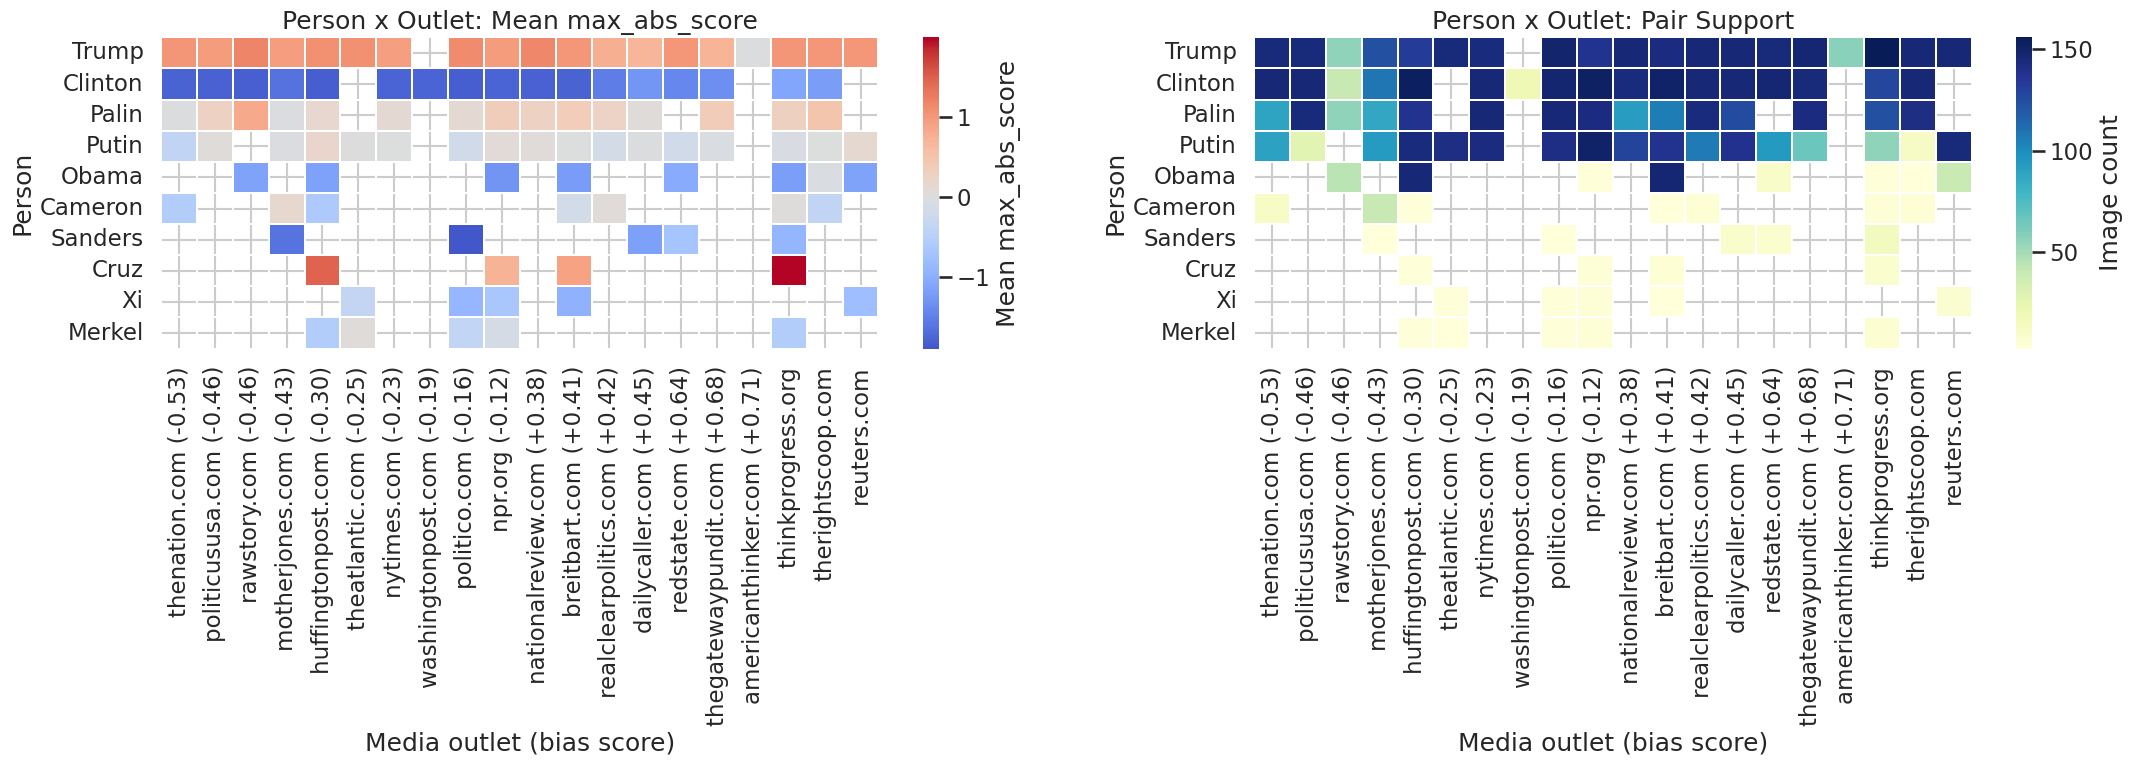

,person,outlet,pair_count,pair_mean_max_abs,pair_median_max_abs
113,Trump,thinkprogress.org,156,1.037625,1.132889
10,Clinton,huffingtonpost.com,153,-1.835489,-1.828491
13,Clinton,npr.org,152,-1.776209,-1.819702
74,Putin,npr.org,150,0.069974,0.401276
8,Clinton,breitbart.com,150,-1.779881,-1.784866
103,Trump,politico.com,149,1.126819,1.144470
15,Clinton,politico.com,148,-1.823403,-1.819275
110,Trump,thegatewaypundit.com,147,0.709662,0.996216
42,Obama,breitbart.com,147,-1.228321,-1.208191
19,Clinton,redstate.com,147,-1.440075,-1.723022


In [24]:
# Person x outlet plot using max-absolute patch score.
import re

if "df_stats" not in globals():
    raise RuntimeError("Run the data-loading cell first so df_stats is available.")
if "max_abs_score" not in df_stats.columns:
    raise ValueError("df_stats does not contain 'max_abs_score'. Re-run the loading cell first.")

if "website_to_moniker_name" not in globals():
    raise RuntimeError("Run the website_to_moniker_name cell first.")

df_group_max = df_stats.copy()

if "image_path" not in df_group_max.columns:
    raise ValueError("Expected column 'image_path' in df_stats.")

def parse_person_outlet(path_str: str):
    p = str(path_str).replace("\\", "/")
    parts = [x for x in p.split("/") if x]
    if len(parts) >= 3:
        person = parts[-3]
        outlet = parts[-2]
    else:
        person = "unknown_person"
        outlet = "unknown_outlet"

    person = re.sub(r"[_-]+", " ", person).strip().title()
    outlet = outlet.strip().lower()
    return person, outlet

parsed = df_group_max["image_path"].apply(parse_person_outlet)
df_group_max[["person", "outlet"]] = pd.DataFrame(parsed.tolist(), index=df_group_max.index)

# Bias mapping from Ad Fontes data.
df_bias = pd.read_csv("data/adfontesmedia.csv")
moniker_to_bias = dict(zip(df_bias["moniker_name"], df_bias["bias_mean"]))
outlet_to_bias = {
    domain: moniker_to_bias[moniker]
    for domain, moniker in website_to_moniker_name.items()
    if moniker is not None and moniker in moniker_to_bias
}

TOP_PERSONS = 20
TOP_OUTLETS = 20
MIN_PAIR_COUNT = 2

person_stats_max = (
    df_group_max.groupby("person", as_index=False)
    .agg(n_images=("max_abs_score", "size"))
    .sort_values("n_images", ascending=False)
)
outlet_stats_max = (
    df_group_max.groupby("outlet", as_index=False)
    .agg(n_images=("max_abs_score", "size"))
    .sort_values("n_images", ascending=False)
)

top_persons = person_stats_max.head(TOP_PERSONS)["person"].tolist()
top_outlets = outlet_stats_max.head(TOP_OUTLETS)["outlet"].tolist()

pair_stats_max = (
    df_group_max[df_group_max["person"].isin(top_persons) & df_group_max["outlet"].isin(top_outlets)]
    .groupby(["person", "outlet"], as_index=False)
    .agg(
        pair_count=("max_abs_score", "size"),
        pair_mean_max_abs=("max_abs_score", "mean"),
        pair_median_max_abs=("max_abs_score", "median"),
    )
)

pair_stats_max = pair_stats_max[pair_stats_max["pair_count"] >= MIN_PAIR_COUNT].copy()

if pair_stats_max.empty:
    print("No person x outlet pairs passed MIN_PAIR_COUNT. Lower MIN_PAIR_COUNT to visualize more pairs.")
else:
    pivot_max = pair_stats_max.pivot(index="person", columns="outlet", values="pair_mean_max_abs")
    pivot_count = pair_stats_max.pivot(index="person", columns="outlet", values="pair_count")

    outlets_in_pivot = list(pivot_max.columns)
    outlets_with_bias = [o for o in outlets_in_pivot if o in outlet_to_bias]
    outlets_without_bias = [o for o in outlets_in_pivot if o not in outlet_to_bias]

    col_order_biased = sorted(outlets_with_bias, key=lambda o: outlet_to_bias[o])
    col_order_fallback = (
        pivot_count[outlets_without_bias].sum(axis=0)
        .sort_values(ascending=False)
        .index.tolist()
    ) if outlets_without_bias else []
    col_order = col_order_biased + col_order_fallback

    row_order = pivot_count.sum(axis=1).sort_values(ascending=False).index

    pivot_max = pivot_max.loc[row_order, col_order]
    pivot_count = pivot_count.loc[row_order, col_order]

    col_labels = [
        f"{o} ({outlet_to_bias[o]:+.2f})" if o in outlet_to_bias else o
        for o in pivot_max.columns
    ]

    fig, axes = plt.subplots(1, 2, figsize=(22, max(8, 0.45 * len(row_order))))

    sns.heatmap(
        pivot_max,
        ax=axes[0],
        cmap="coolwarm",
        center=0.0,
        cbar_kws={"label": "Mean max_abs_score"},
        linewidths=0.2,
        linecolor="white",
        xticklabels=col_labels,
    )
    axes[0].set_title("Person x Outlet: Mean max_abs_score")
    axes[0].set_xlabel("Media outlet (bias score)")
    axes[0].set_ylabel("Person")

    sns.heatmap(
        pivot_count,
        ax=axes[1],
        cmap="YlGnBu",
        cbar_kws={"label": "Image count"},
        linewidths=0.2,
        linecolor="white",
        xticklabels=col_labels,
    )
    axes[1].set_title("Person x Outlet: Pair Support")
    axes[1].set_xlabel("Media outlet (bias score)")
    axes[1].set_ylabel("Person")

    plt.tight_layout()
    plt.show()

display(pair_stats_max.sort_values(["pair_count", "pair_mean_max_abs"], ascending=[False, False]).head(50))